# 09-1. CVAE + Perceptual Loss — PyTorch

기존 CVAE(`checkpoints_cvae_pt/`) 가중치를 불러온 뒤 VGG16 perceptual loss로 파인튜닝합니다.  
새 체크포인트는 `checkpoints_cvae_pl_pt/`에 별도 저장해 기존 모델을 덮어쓰지 않습니다.

| 손실 | 기존 CVAE | Perceptual CVAE |
|------|-----------|----------------|
| Reconstruction | MSE (픽셀 단위) | MSE + λ × VGG 피처 MSE |
| KL | β × KL | β × KL (동일) |

## 1. 환경 설정

In [21]:
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split

_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps


## 2. CFG

In [ ]:
BASE_CKPT_DIR = Path('checkpoints_cvae_pt')
PL_CKPT_DIR   = Path('checkpoints_cvae_pl_pt')
PL_CKPT_DIR.mkdir(exist_ok=True)

with open(BASE_CKPT_DIR / 'config.json') as f:
    BASE_CFG = json.load(f)

ACTIONS     = ['walk', 'idle', 'run', 'slash', 'shoot', 'thrust', 'jump', 'sit', 'spellcast']
LABEL_NAMES = ACTIONS + ['other']

CFG = {
    'latent_dim'   : BASE_CFG['latent_dim'],
    'base_channels': BASE_CFG['base_channels'],
    'channels'     : BASE_CFG['channels'],
    'num_classes'  : BASE_CFG['num_classes'],
    'epochs'       : 50,
    'batch_size'   : 128,
    'lr'           : 1e-4,
    'beta'         : BASE_CFG['beta'],
    'lambda_perc'  : 0.00005,   # to_vgg_scaled 스케일(~수만)에 맞게 조정 — TF의 0.05와 동등
    'patience'     : 10,
}

with open(PL_CKPT_DIR / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

LATENT_DIM  = CFG['latent_dim']
BASE_CH     = CFG['base_channels']
CHANNELS    = CFG['channels']
NUM_CLASSES = CFG['num_classes']
EPOCHS      = CFG['epochs']
BATCH_SIZE  = CFG['batch_size']
LR          = CFG['lr']
BETA        = CFG['beta']
LAMBDA_PERC = CFG['lambda_perc']
PATIENCE    = CFG['patience']
print('CFG:', CFG)

## 3. 데이터셋

In [23]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))

def get_label(path):
    name = Path(path).name
    for i, kw in enumerate(ACTIONS):
        if kw in name: return i
    return len(ACTIONS)

all_labels = [get_label(p) for p in all_paths]
tr_paths, vl_paths, tr_labels, vl_labels = train_test_split(
    all_paths, all_labels, test_size=0.1, random_state=42, stratify=all_labels
)
print(f'Train: {len(tr_paths)}  Val: {len(vl_paths)}')


class SpriteDataset(Dataset):
    def __init__(self, paths, labels, num_classes):
        self.paths      = paths
        self.labels     = labels
        self.num_classes = num_classes
        self.to_tensor  = transforms.ToTensor()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = self.to_tensor(Image.open(self.paths[idx]).convert('RGBA'))
        c   = F.one_hot(torch.tensor(self.labels[idx]), self.num_classes).float()
        return img, c


train_loader = DataLoader(
    SpriteDataset(tr_paths, tr_labels, NUM_CLASSES),
    batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=0
)
val_loader = DataLoader(
    SpriteDataset(vl_paths, vl_labels, NUM_CLASSES),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0
)
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train: 4089  Val: 455
Train batches: 31  Val batches: 4


## 4. CVAE 모델 정의

In [24]:
class CVAEEncoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv  = nn.Sequential(*layers)
        flat_dim   = (base_ch * 8) * 4 * 4
        self.fc_mu = nn.Linear(flat_dim + num_classes, latent_dim)
        self.fc_lv = nn.Linear(flat_dim + num_classes, latent_dim)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = torch.cat([h, c], dim=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim + num_classes, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z, c):
        h = self.fc(torch.cat([z, c], dim=-1))
        return self.deconv(h.view(-1, self.start_ch, 4, 4))


class CVAE(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim, channels)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def forward(self, x, c):
        mu, lv = self.encoder(x, c)
        z      = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z, c), mu, lv


print('Model class defined.')

Model class defined.


## 5. 기존 CVAE 가중치 로드

In [25]:
model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS).to(DEVICE)
model.load_state_dict(torch.load(BASE_CKPT_DIR / 'best.pt', map_location=DEVICE))
print(f'Loaded base CVAE from {BASE_CKPT_DIR}/best.pt')
print(f'Base CFG: beta={BASE_CFG["beta"]}, epochs={BASE_CFG["epochs"]}')

Loaded base CVAE from checkpoints_cvae_pt/best.pt
Base CFG: beta=1.5, epochs=100


## 6. Perceptual Loss (VGG16)

VGG16의 `relu1_2`, `relu2_2` 피처를 사용합니다.

| 전처리 함수 | 스케일 | 비고 |
|------------|--------|------|
| `to_vgg` | [0,1] ImageNet 정규화 | 피처값 작음 → perceptual 약하게 작동 |
| `to_vgg_scaled` | [0,255] BGR mean-subtract (TF 방식) | 피처값 크게 나와 → perceptual 강하게 작동 |

`perceptual_loss`는 `to_vgg_scaled`를 사용합니다.

In [ ]:
class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.slice1 = vgg.features[:4]   # relu1_2
        self.slice2 = vgg.features[4:9]  # relu2_2
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        return h1, h2


vgg_feat = VGGFeatures().to(DEVICE)
vgg_feat.eval()

# to_vgg: [0,1] ImageNet 정규화 (피처값 작음)
_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
_std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

def to_vgg(img_rgba):
    """RGBA [0,1] → white composite RGB → ImageNet normalized"""
    rgb   = img_rgba[:, :3]
    alpha = img_rgba[:, 3:4]
    rgb   = rgb * alpha + (1.0 - alpha)
    return (rgb - _mean) / _std

# to_vgg_scaled: [0,255] BGR mean-subtract (TF preprocess_input 방식, 피처값 크게 나옴)
_bgr_mean = torch.tensor([103.939, 116.779, 123.68]).view(1, 3, 1, 1).to(DEVICE)

def to_vgg_scaled(img_rgba):
    """RGBA [0,1] → white composite RGB → [0,255] BGR → subtract ImageNet BGR means"""
    rgb   = img_rgba[:, :3]
    alpha = img_rgba[:, 3:4]
    rgb   = rgb * alpha + (1.0 - alpha)
    rgb   = rgb * 255.0
    bgr   = rgb[:, [2, 1, 0]]            # RGB → BGR
    return bgr - _bgr_mean


def perceptual_loss(real, fake):
    r1, r2 = vgg_feat(to_vgg_scaled(real))
    f1, f2 = vgg_feat(to_vgg_scaled(fake))
    return F.mse_loss(f1, r1) + F.mse_loss(f2, r2)


print('VGG16 perceptual loss module ready.')
print('  using to_vgg_scaled ([0,255] BGR, TF-style)')

## 7. 파인튜닝

In [27]:
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {'loss': [], 'val_loss': [], 'mse': [], 'perc': [], 'kl': []}
best_val, patience_cnt = float('inf'), 0

for epoch in range(EPOCHS):
    model.train()
    tr_loss = tr_mse = tr_perc = tr_kl = 0.0

    for x, c in train_loader:
        x, c = x.to(DEVICE), c.to(DEVICE)
        recon, mu, lv = model(x, c)
        batch     = x.size(0)
        mse_l     = F.mse_loss(recon, x, reduction='sum') / batch
        perc_l    = perceptual_loss(x, recon)
        kl_l      = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch
        loss      = mse_l + LAMBDA_PERC * perc_l + BETA * kl_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_loss += loss.item(); tr_mse += mse_l.item()
        tr_perc += perc_l.item(); tr_kl += kl_l.item()

    n = len(train_loader)
    tr_loss /= n; tr_mse /= n; tr_perc /= n; tr_kl /= n

    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for x, c in val_loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            recon, mu, lv = model(x, c)
            batch  = x.size(0)
            mse_l  = F.mse_loss(recon, x, reduction='sum') / batch
            perc_l = perceptual_loss(x, recon)
            kl_l   = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch
            vl_loss += (mse_l + LAMBDA_PERC * perc_l + BETA * kl_l).item()
    vl_loss /= max(len(val_loader), 1)

    scheduler.step()

    history['loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['mse'].append(tr_mse)
    history['perc'].append(tr_perc)
    history['kl'].append(tr_kl)

    print(f'Epoch {epoch+1:>3}/{EPOCHS}  '
          f'loss={tr_loss:.2f}  mse={tr_mse:.2f}  perc={tr_perc:.4f}  kl={tr_kl:.2f}  '
          f'val={vl_loss:.2f}  lr={scheduler.get_last_lr()[0]:.6f}')

    if vl_loss < best_val:
        best_val = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), PL_CKPT_DIR / 'best.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(torch.load(PL_CKPT_DIR / 'best.pt', map_location=DEVICE))
print(f'\nBest val_loss: {best_val:.4f}')

Epoch   1/100  loss=70.73  mse=38.91  perc=3.6646  kl=18.77  val=75.83  lr=0.000100
Epoch   2/100  loss=70.41  mse=38.45  perc=3.5677  kl=18.93  val=75.56  lr=0.000100
Epoch   3/100  loss=70.07  mse=38.11  perc=3.5081  kl=18.97  val=74.98  lr=0.000100
Epoch   4/100  loss=70.01  mse=38.01  perc=3.4615  kl=19.02  val=75.62  lr=0.000100
Epoch   5/100  loss=69.50  mse=37.59  perc=3.4120  kl=19.00  val=74.92  lr=0.000099
Epoch   6/100  loss=69.29  mse=37.55  perc=3.3897  kl=18.90  val=74.53  lr=0.000099
Epoch   7/100  loss=69.03  mse=37.17  perc=3.3511  kl=19.01  val=74.07  lr=0.000099
Epoch   8/100  loss=68.73  mse=36.88  perc=3.3059  kl=19.03  val=74.20  lr=0.000098
Epoch   9/100  loss=68.60  mse=36.91  perc=3.2948  kl=18.93  val=73.88  lr=0.000098
Epoch  10/100  loss=68.41  mse=36.64  perc=3.2601  kl=19.01  val=73.59  lr=0.000098
Epoch  11/100  loss=68.27  mse=36.55  perc=3.2408  kl=18.99  val=73.36  lr=0.000097
Epoch  12/100  loss=68.07  mse=36.27  perc=3.2059  kl=19.06  val=73.30  lr=0

## 8. 학습 곡선

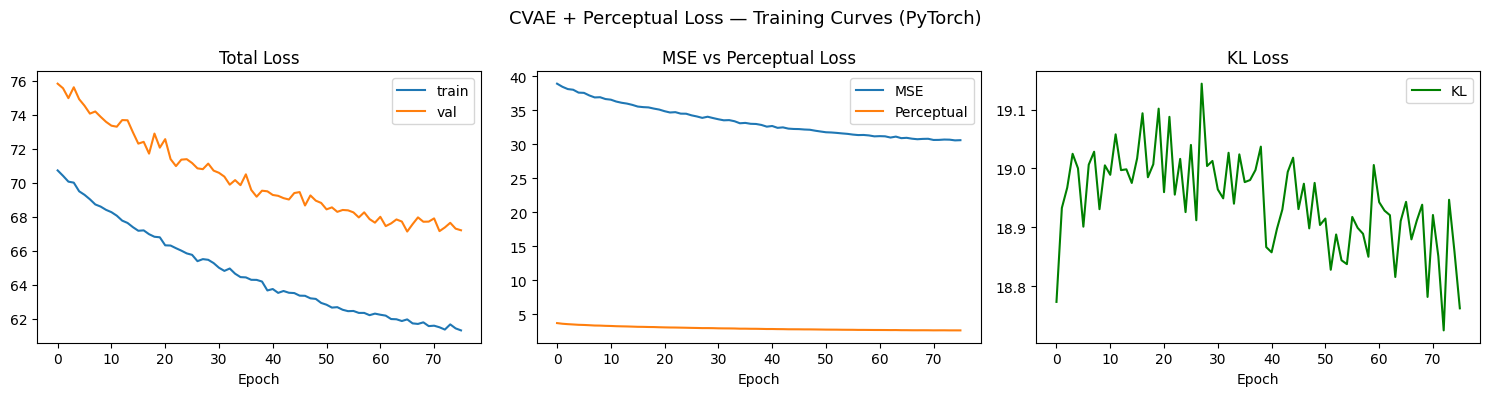

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'],     label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['mse'],  label='MSE')
axes[1].plot(history['perc'], label='Perceptual')
axes[1].set_title('MSE vs Perceptual Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['kl'], label='KL', color='green')
axes[2].set_title('KL Loss'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('CVAE + Perceptual Loss — Training Curves (PyTorch)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. 복원 결과 비교 (Base CVAE vs Perceptual CVAE)

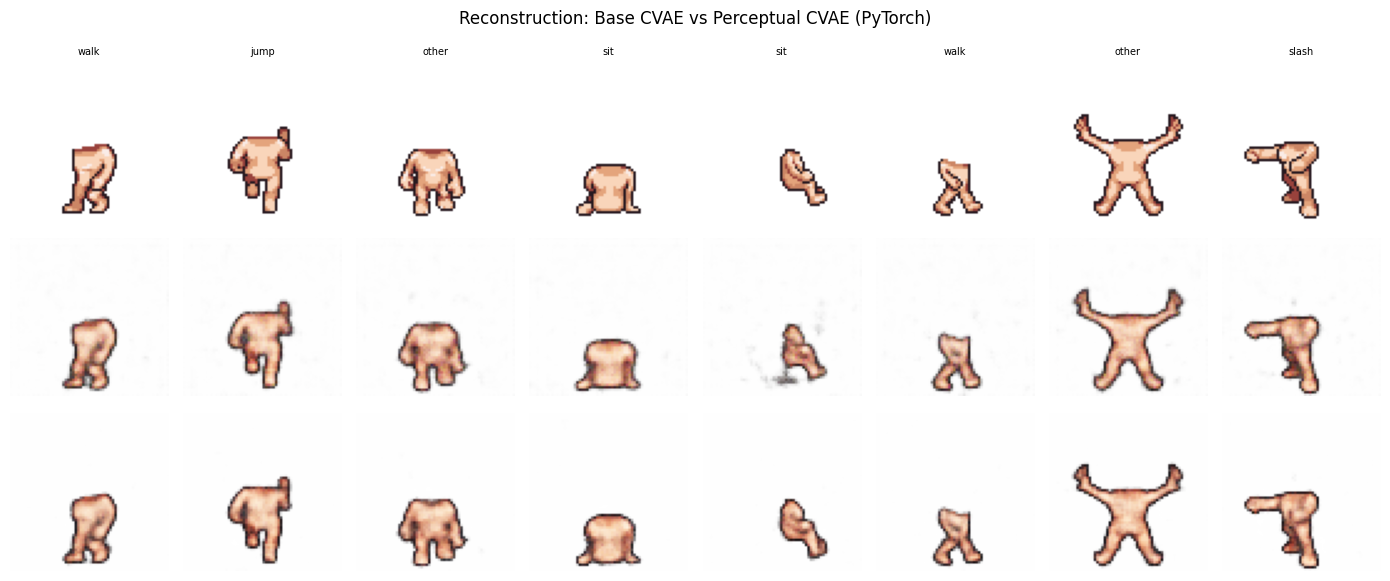

In [29]:
base_model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(BASE_CKPT_DIR / 'best.pt', map_location=DEVICE))
base_model.eval()


def composite(t):
    # t: (C, H, W) tensor [0,1]
    t = t.permute(1, 2, 0).cpu().numpy()
    rgb, a = t[..., :3], t[..., 3:4]
    return np.clip(rgb * a + (1.0 - a), 0, 1)


sample_x, sample_c = next(iter(val_loader))
sample_x = sample_x[:8].to(DEVICE)
sample_c = sample_c[:8].to(DEVICE)

model.eval()
with torch.no_grad():
    base_recon, _, _ = base_model(sample_x, sample_c)
    pl_recon,   _, _ = model(sample_x, sample_c)

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
row_labels = ['Original', 'Base CVAE', 'Perceptual CVAE']
for i in range(8):
    lbl = sample_c[i].argmax().item()
    axes[0, i].imshow(composite(sample_x[i]))
    axes[0, i].set_title(LABEL_NAMES[lbl], fontsize=7)
    axes[1, i].imshow(composite(base_recon[i]))
    axes[2, i].imshow(composite(pl_recon[i]))
    for row in range(3):
        axes[row, i].axis('off')

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=9)

plt.suptitle('Reconstruction: Base CVAE vs Perceptual CVAE (PyTorch)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. 조건부 생성 비교

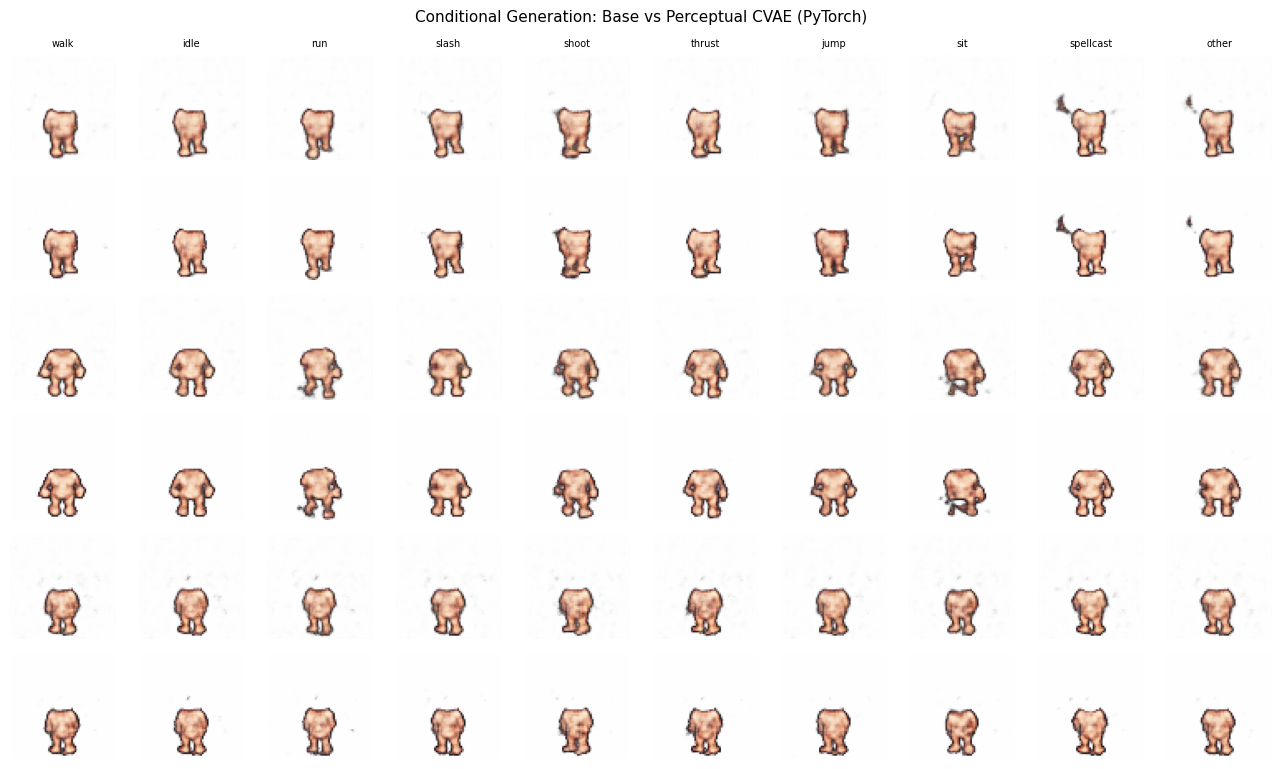

In [30]:
N_ROWS = 3
torch.manual_seed(0)
z_samples = torch.randn(N_ROWS, LATENT_DIM).to(DEVICE)

fig, axes = plt.subplots(N_ROWS * 2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.3, N_ROWS * 2.6))

model.eval()
with torch.no_grad():
    for row in range(N_ROWS):
        for col in range(NUM_CLASSES):
            c = F.one_hot(torch.tensor([col]), NUM_CLASSES).float().to(DEVICE)
            z = z_samples[row:row+1]

            base_img = base_model.decoder(z, c)
            pl_img   = model.decoder(z, c)

            r0 = row * 2
            axes[r0,   col].imshow(composite(base_img[0]))
            axes[r0+1, col].imshow(composite(pl_img[0]))
            axes[r0,   col].axis('off')
            axes[r0+1, col].axis('off')
            if row == 0:
                axes[r0, col].set_title(LABEL_NAMES[col], fontsize=7)
        axes[row*2,   0].set_ylabel('Base', fontsize=8)
        axes[row*2+1, 0].set_ylabel('+ Perc', fontsize=8)

plt.suptitle('Conditional Generation: Base vs Perceptual CVAE (PyTorch)', fontsize=11)
plt.tight_layout()
plt.show()